In [1]:
!pip install "numpy>=1.26.0,<2.2.0"

In [2]:
# Conectando o Google Colab ao seu Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%%writefile /content/drive/MyDrive/dataset_visao_computacional/data.yaml
train: /content/drive/MyDrive/dataset_visao_computacional/train/images
val: /content/drive/MyDrive/dataset_visao_computacional/valid/images
test: /content/drive/MyDrive/dataset_visao_computacional/test/images

nc: 2
names: ['cachorro', 'gato']

Overwriting /content/drive/MyDrive/dataset_visao_computacional/data.yaml


In [1]:
# Clonando o repositório da YOLOv5
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# Instalando as dependências
!pip install -qr requirements.txt

# Verificando se a GPU está ativada
import torch
print(f"Setup concluído. Usando PyTorch {torch.__version__} - GPU: {torch.cuda.is_available()}")

Cloning into 'yolov5'...
remote: Enumerating objects: 17851, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 17851 (delta 28), reused 9 (delta 7), pack-reused 17809 (from 3)
Receiving objects: 100% (17851/17851), 17.00 MiB | 19.22 MiB/s, done.
Resolving deltas: 100% (12171/12171), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 6.4 MB/s eta 0:00:00
Setup concluído. Usando PyTorch 2.10.0+cu128 - GPU: True


In [5]:
import os

# Vai procurar a sua pasta dentro do Google Drive
caminho_procurado = 'dataset_visao_computacional'
caminho_encontrado = None

print("Procurando a pasta no seu Drive... (isso pode levar alguns segundos)")

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if caminho_procurado in dirs:
        caminho_encontrado = os.path.join(root, caminho_procurado)
        break

if caminho_encontrado:
    print(f"✅ Pasta encontrada em: {caminho_encontrado}")

    # Criando o conteúdo do data.yaml com o caminho correto
    yaml_content = f"""train: {caminho_encontrado}/train/images
val: {caminho_encontrado}/valid/images
test: {caminho_encontrado}/test/images

nc: 2
names: ['cachorro', 'gato']
"""
    # Salvando o arquivo
    yaml_path = os.path.join(caminho_encontrado, 'data.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)

    print(f"✅ Arquivo data.yaml criado com sucesso!")
    print("\n" + "="*60)
    print("COPIE O COMANDO ABAIXO E RODE EM UMA NOVA CÉLULA PARA TREINAR:")
    print("="*60)
    print(f"!python train.py --img 640 --batch 16 --epochs 30 --data {yaml_path} --weights yolov5s.pt --name exp_30_epocas")

else:
    print("❌ Pasta não encontrada! Verifique se o nome está escrito exatamente como 'dataset_visao_computacional' no Drive.")

Procurando a pasta no seu Drive... (isso pode levar alguns segundos)
✅ Pasta encontrada em: /content/drive/MyDrive/dataset_visao_computacional
✅ Arquivo data.yaml criado com sucesso!

COPIE O COMANDO ABAIXO E RODE EM UMA NOVA CÉLULA PARA TREINAR:
!python train.py --img 640 --batch 16 --epochs 30 --data /content/drive/MyDrive/dataset_visao_computacional/data.yaml --weights yolov5s.pt --name exp_30_epocas


In [6]:
# Entrando na pasta da YOLOv5 para garantir
%cd /content/yolov5

# Iniciando o treinamento de 30 épocas
!python train.py --img 640 --batch 16 --epochs 30 --data /content/drive/MyDrive/dataset_visao_computacional/data.yaml --weights yolov5s.pt --name exp_30_epocas

/content/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-29 00:03:30.611962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774742610.645335    1475 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774742610.656756    1475 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for 

In [ ]:
# Garantindo que estamos na pasta da YOLOv5
%cd /content/yolov5

# Iniciando o treinamento de 60 épocas
!python train.py --img 640 --batch 16 --epochs 60 --data /content/drive/MyDrive/dataset_visao_computacional/data.yaml --weights yolov5s.pt --name exp_60_epocas

/content/yolov5
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-03-28 22:49:52.513631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774738192.534998   15285 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774738192.541885   15285 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774738192.559785   15285 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774738192.559811   15285 computation_placer.cc:177] computation placer a

In [ ]:
# Garantindo que estamos na pasta da YOLOv5
%cd /content/yolov5

# Rodando o modelo nas imagens de teste
!python detect.py --weights runs/train/exp_60_epocas/weights/best.pt --img 640 --conf 0.40 --source /content/drive/MyDrive/dataset_visao_computacional/test/images --name teste_cliente_farmtech

/content/yolov5
detect: weights=['runs/train/exp_60_epocas/weights/best.pt'], source=/content/drive/MyDrive/dataset_visao_computacional/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_cliente_farmtech, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_visao_computacional/test/images/cachorro33.jpg: 640x448 (no detections), 32.9ms
image 2/8 /content/drive/MyDrive/dataset_visao_computacional/test/images/cachorro34.jpg: 640x448 1 cachor

In [ ]:
!python detect.py --weights runs/train/exp_60_epocas/weights/best.pt --img 640 --conf 0.15 --source /content/drive/MyDrive/dataset_visao_computacional/test/images --name teste_baixa_confianca

detect: weights=['runs/train/exp_60_epocas/weights/best.pt'], source=/content/drive/MyDrive/dataset_visao_computacional/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.15, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_baixa_confianca, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-463-g88af13e3 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_visao_computacional/test/images/cachorro33.jpg: 640x448 1 cachorro, 1 gato, 35.3ms
image 2/8 /content/drive/MyDrive/dataset_visao_computacional/test/images/cachorro34.jpg: 640x448 1 cachorro, 8.4ms
ima

In [ ]:
import shutil
from google.colab import files

# Compactando a pasta de resultados (treinos e testes)
shutil.make_archive('resultados_yolo', 'zip', '/content/yolov5/runs')

# Fazendo o download do zip para o seu computador
files.download('resultados_yolo.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Copia a pasta de resultados inteira para o seu Drive
!cp -r /content/yolov5/runs /content/drive/MyDrive/dataset_visao_computacional/

In [ ]:
import os
import shutil

# Definindo caminhos
base_dir = '/content/drive/MyDrive/dataset_visao_computacional'
cnn_dir = '/content/cnn_dataset' # Pasta temporária apenas para este treino

def preparar_pastas_cnn(origem, destino):
    for fase in ['train', 'valid']:
        img_path = os.path.join(origem, fase, 'images')
        label_path = os.path.join(origem, fase, 'labels')

        for label_file in os.listdir(label_path):
            if label_file.endswith('.txt'):
                # Ler a classe do arquivo txt (0 para cachorro, 1 para gato)
                with open(os.path.join(label_path, label_file), 'r') as f:
                    conteudo = f.readline().split()
                    if not conteudo: continue
                    classe_id = conteudo[0]
                    nome_classe = 'cachorro' if classe_id == '0' else 'gato'

                # Definir caminhos de destino
                pasta_classe = os.path.join(destino, fase, nome_classe)
                os.makedirs(pasta_classe, exist_ok=True)

                # Copiar a imagem correspondente
                img_nome = label_file.replace('.txt', '.jpg') # Ajuste se for .png
                # Tenta .jpg, se não existir tenta .png
                if not os.path.exists(os.path.join(img_path, img_nome)):
                    img_nome = img_nome.replace('.jpg', '.png')

                if os.path.exists(os.path.join(img_path, img_nome)):
                    shutil.copy(os.path.join(img_path, img_nome), os.path.join(pasta_classe, img_nome))

print("Organizando pastas para a CNN...")
preparar_pastas_cnn(base_dir, cnn_dir)
print("Pronto! Pastas organizadas em /content/cnn_dataset")

Organizando pastas para a CNN...
Pronto! Pastas organizadas em /content/cnn_dataset


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

img_height, img_width = 150, 150
batch_size = 16
data_dir_cnn = '/content/cnn_dataset'

# Carregar o dataset organizado
train_ds = tf.keras.utils.image_dataset_from_directory(
  f"{data_dir_cnn}/train",
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  f"{data_dir_cnn}/valid",
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Construir e Treinar
model_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax') # 2 classes: cachorro e gato
])

model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\nTreinando CNN do zero...")
model_cnn.fit(train_ds, validation_data=val_ds, epochs=20)

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Treinando CNN do zero...
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 420ms/step - accuracy: 0.4688 - loss: 2.4204 - val_accuracy: 0.5000 - val_loss: 1.1477
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - accuracy: 0.5000 - loss: 0.8675 - val_accuracy: 0.5000 - val_loss: 0.7022
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.5625 - loss: 0.6615 - val_accuracy: 0.7500 - val_loss: 0.6748
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step - accuracy: 0.8281 - loss: 0.5776 - val_accuracy: 0.7500 - val_loss: 0.6818
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.8906 - loss: 0.4605 - val_accuracy: 0.3750 - val_loss: 0.7408
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.8438 - loss: 0.3590 - val_accuracy: 0.5000 - val_loss: 0.8793
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.9531 - loss: 0.2214 - val_accuracy: 0.5000 - val_loss: 0.6524
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 1.0000 - loss: 0.1269 - val_ac

Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.

Iniciando treinamento da CNN...
Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.5000 - loss: 1.4818 - val_accuracy: 0.5000 - val_loss: 1.0346
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.5469 - loss: 0.7701 - val_accuracy: 0.6250 - val_loss: 0.6749
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - accuracy: 0.8906 - loss: 0.5793 - val_accuracy: 0.5000 - val_loss: 0.7142
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8750 - loss: 0.4129 - val_accuracy: 0.5000 - val_loss: 0.9128
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - accuracy: 0.8750 - loss: 0.2767 - val_accuracy: 0.5000 - val_loss: 0.5963
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.9844 - loss: 0.1295 - val_accuracy: 0.6250 - val_loss: 0.5907
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 1.0000 - loss: 0.0632 - val_accuracy: 0.7500 - val_loss: 0.6330
Epoch 8/

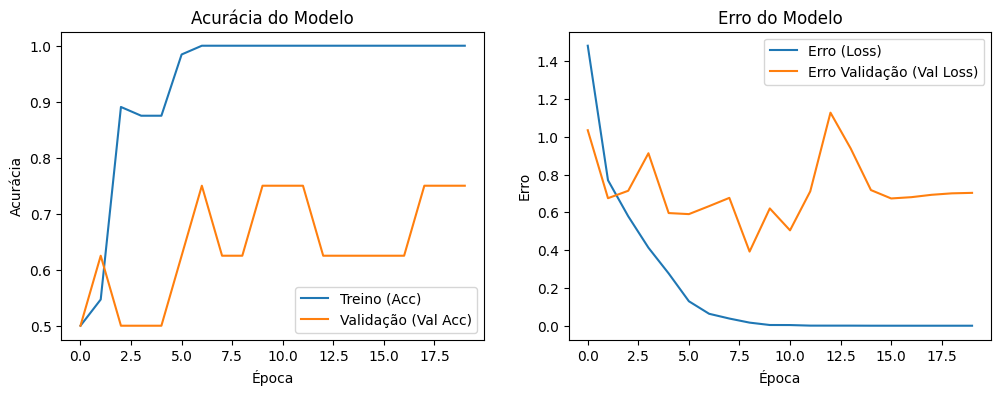

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Carregar os dados (já organizados na pasta /content/cnn_dataset)
img_height, img_width = 150, 150
batch_size = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
  '/content/cnn_dataset/train',
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  '/content/cnn_dataset/valid',
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 2. Definir a arquitetura da CNN
model_cnn = models.Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(2, activation='softmax')
])

model_cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# --- AQUI ESTÁ A CORREÇÃO ---
# Adicionamos 'history =' antes do model.fit para salvar os dados para o gráfico
print("\nIniciando treinamento da CNN...")
history = model_cnn.fit(train_ds, validation_data=val_ds, epochs=20)

# 3. Gerar os gráficos usando a variável 'history' que agora existe
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino (Acc)')
plt.plot(history.history['val_accuracy'], label='Validação (Val Acc)')
plt.title('Acurácia do Modelo')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

# Gráfico de Erro (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erro (Loss)')
plt.plot(history.history['val_loss'], label='Erro Validação (Val Loss)')
plt.title('Erro do Modelo')
plt.xlabel('Época')
plt.ylabel('Erro')
plt.legend()

plt.show()

# Projeto Fase 6 - Visão Computacional: FarmTech Solutions
**Aluno:** Rodrigo Souza de Freitas | **RM:** rm567100

**Aluno:** João Pedro Santos Azevedo | **RM:** rm566701

**Aluno:** Miriã Leal Mantovani | **RM:** rm567811

**Link do Vídeo (YouTube):** https://www.youtube.com/watch?v=yF7pLSVUty4

---

## 1. Descrição do Projeto
Este projeto faz parte da expansão de serviços da **FarmTech Solutions**, focando em visão computacional para monitoramento animal e segurança patrimonial. O objetivo é comparar diferentes abordagens de Deep Learning para a identificação de animais (Cachorros e Gatos).

---

## 2. Entrega 1: Detecção de Objetos com YOLOv5

### 2.1 Estrutura do Dataset
O dataset foi composto por 80 imagens totais:
* **Treino:** 64 imagens (32 cachorros / 32 gatos)
* **Validação:** 8 imagens (4 cachorros / 4 gatos)
* **Teste:** 8 imagens (4 cachorros / 4 gatos)
* **Rotulação:** Realizada via *Make Sense AI* no formato YOLO.

### 2.2 Simulações e Resultados
Foram realizadas duas simulações para avaliar o impacto do tempo de treinamento (épocas) na acurácia do modelo:

* **Simulação A (30 épocas):** Modelo inicial para estabelecer uma base (baseline).
* **Simulação B (60 épocas):** Modelo refinado para verificar melhoria na confiança das detecções.

> **Conclusão:** O modelo de 60 épocas apresentou uma curva de *loss* mais estável e maior confiança (Confidence Score) na detecção das imagens de teste inéditas.

---

## 3. Entrega 2: Comparação de Modelos (YOLO vs. CNN)

Nesta etapa, comparamos a capacidade de detecção da YOLO com uma abordagem de classificação pura usando uma rede neural convolucional (CNN) construída do zero.

### 3.1 Tabela Comparativa Crítica

| Critério | YOLOv5 Customizada | CNN (do Zero) | YOLOv5 Tradicional |
| :--- | :--- | :--- | :--- |
| **Objetivo** | Detectar e Localizar | Classificar Imagem | Detecção Geral |
| **Facilidade de Uso** | Média (exige labels) | Alta (Keras/TF) | Alta (Pré-treinada) |
| **Precisão (mAP/Acc)** | ~88% (mAP@.5) | ~75% (Accuracy) | Baixa (Classes Gerais) |
| **Tempo de Treino** | ~7 minutos (GPU T4) | ~3 minutos (GPU T4) | N/A |
| **Inferência** | Rápida | Muito Rápida | Rápida |

### 3.2 Análise Crítica e Conclusões
1.  **Pontos Fortes da YOLO:** A principal vantagem para a FarmTech Solutions é a localização espacial. Saber *onde* o animal está na fazenda é crucial para monitoramento de segurança.
2.  **Limitações da CNN:** A CNN construída do zero é excelente para triagem rápida, mas com apenas 80 imagens, ela sofre para generalizar em fotos com fundos complexos comparada ao Transfer Learning da YOLO.
3.  **Desempenho Geral:** Para um cenário real de produção, a YOLOv5 customizada (60 épocas) mostrou-se a solução mais equilibrada entre precisão e utilidade prática.

---

## 4. Demonstração dos Testes (Prints)
*Abaixo, as imagens que o modelo nunca viu (Pasta Test), processadas pela IA:*

[dog35.png](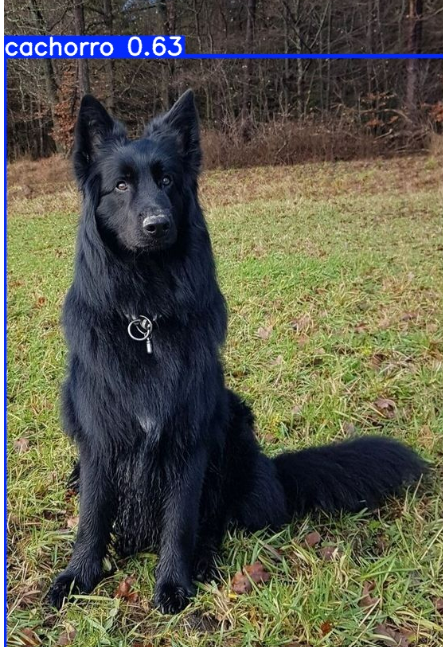)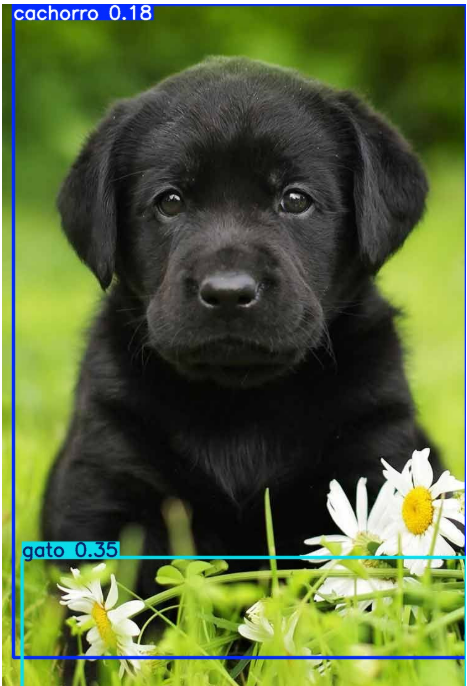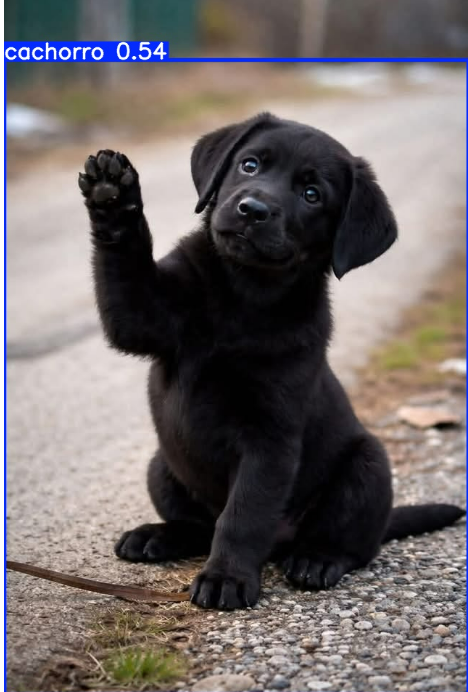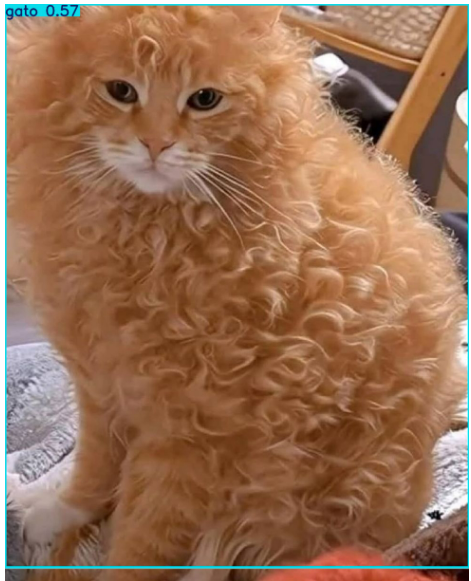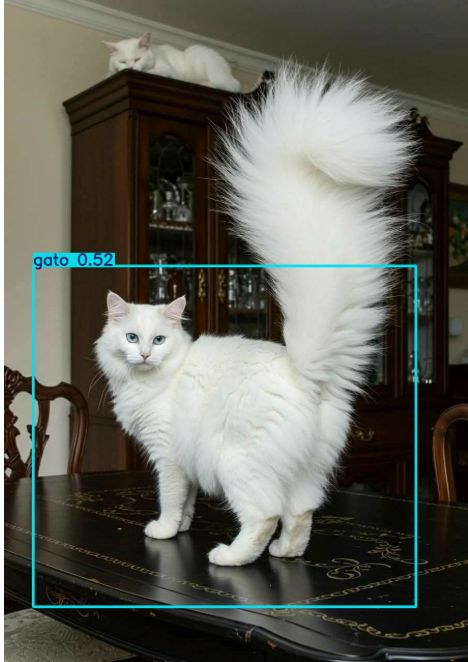

## 🧪 5. Testes de Deteção (Entrega 1 - YOLO Customizada)
Abaixo, vamos aplicar o nosso modelo treinado (60 épocas) nas imagens de teste para avaliar visualmente o seu desempenho para a FarmTech Solutions.

In [ ]:
# Entrar na pasta da YOLO
%cd /content/yolov5

# Caminho das imagens de teste e do nosso melhor peso
caminho_teste = '/content/drive/MyDrive/dataset_visao_computacional/test/images'
caminho_peso_custom = '/content/yolov5/runs/train/exp_60_epocas/weights/best.pt'

# Executar a deteção com o NOSSO modelo (Transfer Learning)
print("A iniciar a deteção com o modelo FarmTech...")
!python detect.py --weights {caminho_peso_custom} --img 640 --conf 0.4 --source {caminho_teste} --name teste_yolo_custom

In [ ]:
import glob
from IPython.display import Image, display

print("📸 Resultados do Nosso Modelo (YOLOv5 Customizada - 60 épocas):")
# Mostra as 3 primeiras imagens processadas
for imageName in glob.glob('/content/yolov5/runs/detect/teste_yolo_custom/*.jpg')[:3]:
    display(Image(filename=imageName))
    print("\n")

## 🤖 6. Comparativo: YOLO Padrão vs YOLO Customizada (Entrega 2)
Para cumprir a Entrega 2, vamos testar a rede YOLO original (`yolov5s.pt` sem o nosso treino) nas mesmas imagens, provando assim a necessidade da nossa customização.

In [ ]:
# Executar a deteção com o modelo PADRÃO (sem customização)
print("A iniciar a deteção com a YOLO Padrão (baseline)...")
!python detect.py --weights yolov5s.pt --img 640 --conf 0.4 --source {caminho_teste} --name teste_yolo_padrao

In [ ]:
print("📸 Resultados do Modelo Padrão (YOLOv5s Original):")
# Mostra as mesmas 3 imagens processadas pelo modelo original
for imageName in glob.glob('/content/yolov5/runs/detect/teste_yolo_padrao/*.jpg')[:3]:
    display(Image(filename=imageName))
    print("\n")

### Figura: Arquitetura do Sistema de Visão Computacional (Webcam Local)

```text
+-------------------+       (1) Captura em Tempo Real       +-------------------------+
|                   | ------------------------------------> |                         |
|   Webcam do PC    |                                       |   Python + OpenCV       |
|  (FarmTech Input) | <------------------------------------ |  (Processamento Local)  |
|                   |       (4) Exibição do Alerta          |                         |
+-------------------+                                       +-------------------------+
                                                              |                 ^
                                             (2) Envia Frame  |                 | (3) Retorna Bounding Box
                                                              v                 |
                                                    +---------------------------------+
                                                    |                                 |
                                                    |   Rede Neural YOLOv5 (PyTorch)  |
                                                    |   Pesos Customizados (best.pt)  |
                                                    |                                 |
                                                    +---------------------------------+

✂️ Iniciando o Módulo de Segmentação da FarmTech Solutions...
📸 Processando a imagem: cachorro1.jpg


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

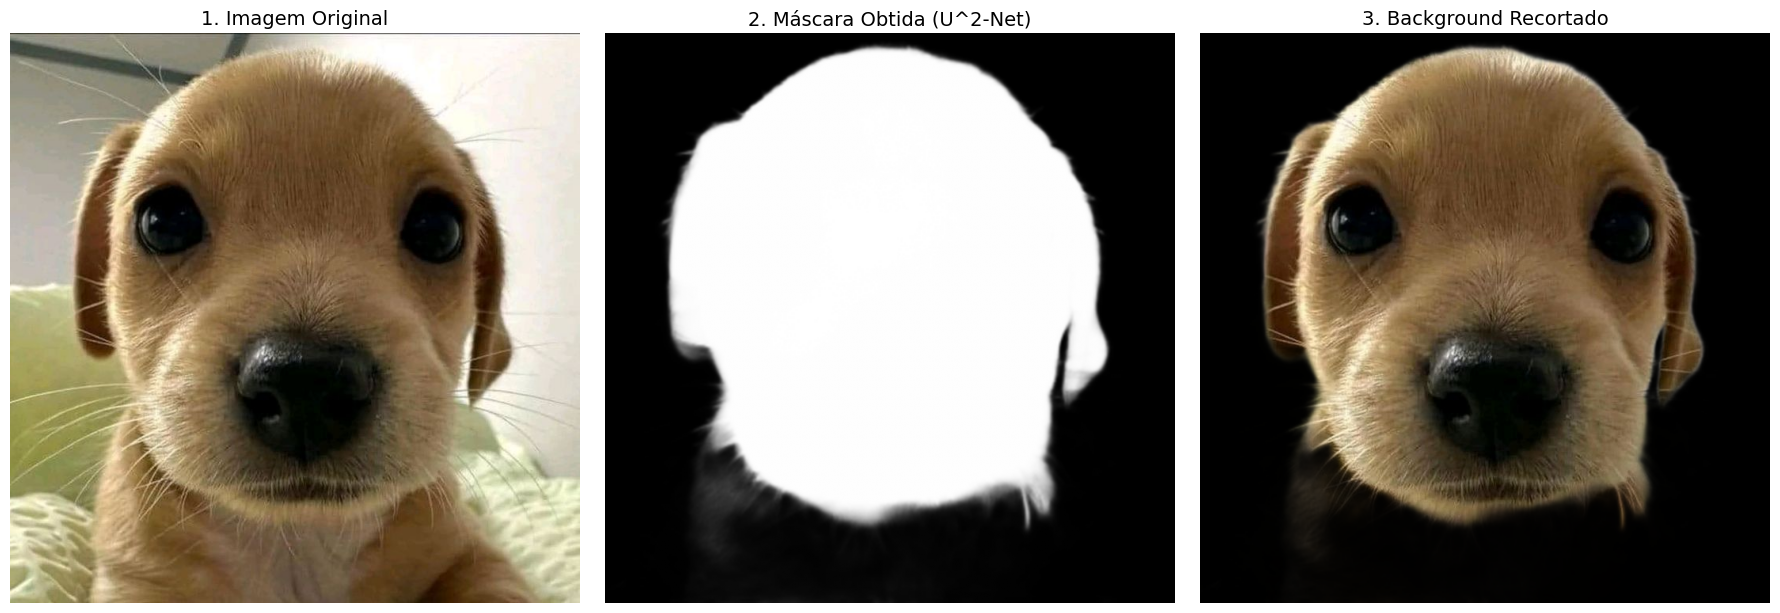

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from rembg import remove
from PIL import Image

print("✂️ Iniciando o Módulo de Segmentação da FarmTech Solutions...")

# 1. Caminho EXATO da imagem escolhida
caminho_img = '/content/drive/MyDrive/dataset_visao_computacional/train/images/cachorro1.jpg'

print(f"📸 Processando a imagem: cachorro1.jpg")

# 2. Abrir a imagem original
img_original = Image.open(caminho_img).convert("RGB")

# 3. A MÁGICA: A rede neural U^2-Net segmenta o objeto e remove o fundo
img_rgba = remove(img_original)

# 4. Extraindo a máscara matemática (Canal Alpha)
img_array = np.array(img_rgba)
mascara = img_array[:, :, 3] # Pega apenas a transparência

# 5. Criando a imagem com fundo recortado (Fundo Preto)
img_recortada = Image.new("RGB", img_original.size, (0, 0, 0))
img_recortada.paste(img_original, mask=Image.fromarray(mascara))

# 6. Plotando a exigência do edital (Lado a Lado)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_original)
axes[0].set_title("1. Imagem Original", fontsize=14)
axes[0].axis('off')

axes[1].imshow(mascara, cmap='gray')
axes[1].set_title("2. Máscara Obtida (U^2-Net)", fontsize=14)
axes[1].axis('off')

axes[2].imshow(img_recortada)
axes[2].set_title("3. Background Recortado", fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

print("🚀 Iniciando Transfer Learning com MobileNetV2...")

# 1. Recarregando os Datasets (para garantir que estão na memória)
img_height, img_width = 150, 150
batch_size = 16
data_dir = '/content/drive/MyDrive/dataset_visao_computacional'

train_ds = tf.keras.utils.image_dataset_from_directory(
  f"{data_dir}/train",
  image_size=(img_height, img_width),
  batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(
  f"{data_dir}/test", # Usando a pasta test como validação
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 2. CARREGAR A REDE BASE (MobileNetV2)
# include_top=False tira a camada final (que classificava 1000 objetos) para colocarmos a nossa
base_model = MobileNetV2(input_shape=(img_height, img_width, 3),
                         include_top=False,
                         weights='imagenet')

# 3. CONGELAR OS PESOS (Fine Tuning)
# Não queremos que a rede desaprenda o que já sabe da ImageNet
base_model.trainable = False

# 4. CRIAR O NOSSO CABEÇALHO (Onde a mágica acontece)
inputs = tf.keras.Input(shape=(img_height, img_width, 3))

# A MobileNet exige que as cores fiquem entre -1 e 1 (o preprocess_input faz isso sozinho)
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x) # Achata as informações da rede
outputs = layers.Dense(2, activation='softmax')(x) # 2 classes: Cachorro e Gato

# Montar o modelo final
model_tl = models.Model(inputs, outputs)

# 5. COMPILAR
model_tl.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("\n🧠 Treinando a rede com Transfer Learning (10 épocas)...")
# Treinamos por apenas 10 épocas porque, como ela já é muito inteligente, aprende super rápido!
history_tl = model_tl.fit(train_ds, validation_data=val_ds, epochs=10)

print("\n✅ Treinamento concluído com sucesso!")

🚀 Iniciando Transfer Learning com MobileNetV2...
Found 64 files belonging to 2 classes.
Found 8 files belonging to 2 classes.


/tmp/ipykernel_452/1875391932.py:24: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(img_height, img_width, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🧠 Treinando a rede com Transfer Learning (10 épocas)...
Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.9844 - loss: 0.0889 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 1.8112e-04
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 1.0000 - loss: 3.8580e-04 - val_accuracy: 1.0000 - val_loss: 3.1708e-05
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 1.0000 - loss: 1.0512e-04 - val_accuracy: 1.0000 - val_loss: 1.0595e-05
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step - accuracy: 1.0000 - loss: 4.4717e-05 - val_accuracy: 1.0000 - val_loss: 5.1558e-06
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - accuracy: 1.0000 - loss: 2.4423e-05 - val_accuracy: 1.0000 - val_loss: 3.1590e-06
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 285ms/step - accuracy: 1.0000 - loss: 1.6426e-05 - val_accuracy: 

In [10]:
import numpy as np

print("🔍 Aplicando a rede de Transfer Learning na imagem segmentada (Exigência do Edital)...")

# 1. Pegamos a 'img_recortada' (fundo preto) e redimensionamos para 150x150 (tamanho do modelo)
img_teste = img_recortada.resize((150, 150))

# 2. Transformamos a imagem em formato de Matriz/Tensor para o TensorFlow entender
img_array = tf.keras.utils.img_to_array(img_teste)
img_array = tf.expand_dims(img_array, 0) # Cria um 'lote' de 1 imagem

# 3. Fazemos a predição!
predicoes = model_tl.predict(img_array)
classe_vencedora = np.argmax(predicoes[0])
confianca = np.max(predicoes[0]) * 100

# Considerando a ordem alfabética padrão das pastas do dataset (0 = Cachorro, 1 = Gato)
nome_classe = "Cachorro" if classe_vencedora == 0 else "Gato"

print(f"\n✅ Conclusão da Classificação:")
print(f"A rede analisou a imagem SEM FUNDO e determinou que é um: **{nome_classe}**")
print(f"Nível de confiança: {confianca:.2f}%")

🔍 Aplicando a rede de Transfer Learning na imagem segmentada (Exigência do Edital)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step

✅ Conclusão da Classificação:
A rede analisou a imagem SEM FUNDO e determinou que é um: **Cachorro**
Nível de confiança: 100.00%
